In [1]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
pylab.rcParams.update({
    "legend.fontsize": "medium", "figure.figsize": (18, 6),
    "axes.labelsize": "medium", "axes.titlesize": "medium",
    "xtick.labelsize": "medium", "ytick.labelsize": "medium",
})

import datetime
import os
import sys

import numpy as np
import pandas as pd
import pytz

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
NYC_tz = pytz.timezone("America/New_York")
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

In [11]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

# curve_mdp = IRSwapsMDP(source="CITIVELO_EXCEL")
curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
vol_mdp = IRSwaptionMDP(
    source="CITIVELO-RL",
    curve_source="citivelo_excel_rl",
    request_defaults={"verify": False},
)


start = datetime.date(2023, 1, 1)
end = datetime.date(2026, 8, 25)

In [37]:
COLOURS = ["WHITES", "REDS", "GREENS", "BLUES", "GOLDS", "Z26"]
COLOURS_MODEL = ["WHITES_MODEL", "REDS_MODEL", "GREENS_MODEL", "BLUES_MODEL", "GOLDS_MODEL"]
ca_df = IRSwapsTB(curve_mdp, show_tqdm=True).sfr_cvx_adj(COLOURS + COLOURS_MODEL, start, end)
ca_df


WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  8.63it/s]


,USD-SOFR-1D WHITES_MODEL PACKS CVX_ADJ,USD-SOFR-1D REDS_MODEL PACKS CVX_ADJ,USD-SOFR-1D GREENS_MODEL PACKS CVX_ADJ,USD-SOFR-1D BLUES_MODEL PACKS CVX_ADJ,USD-SOFR-1D GOLDS_MODEL PACKS CVX_ADJ,USD-SOFR-1D WHITES PACKS CVX_ADJ,USD-SOFR-1D REDS PACKS CVX_ADJ,USD-SOFR-1D GREENS PACKS CVX_ADJ,USD-SOFR-1D BLUES PACKS CVX_ADJ,USD-SOFR-1D GOLDS PACKS CVX_ADJ,USD-SOFR-1D Z26 OUTRIGHT CVX_ADJ
Date,,,,,,,,,,,
2023-01-03,0.344611,2.569541,6.404078,11.261601,16.416603,1.000979,5.443960,5.071216,10.737595,18.278549,12.723189
2023-01-04,0.326642,2.440525,6.121076,10.881983,15.951156,2.551794,3.963245,5.257072,12.511351,19.358071,14.230974
2023-01-05,0.298203,2.281445,5.810810,10.315825,14.961574,0.913003,6.279041,4.994146,12.386524,20.988248,15.550703
2023-01-06,0.274758,2.108170,5.398788,9.657205,14.195847,1.056826,4.859519,5.521231,11.559818,18.256925,13.214586
2023-01-09,0.265222,2.003902,5.099018,9.091265,13.498074,1.187043,4.280657,6.113516,13.429119,20.662487,15.728910
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-19,0.107754,0.974959,2.718713,5.206032,8.357875,1.780621,-0.782571,2.623165,5.997563,9.439120,1.503417
2026-08-20,0.108230,1.004945,2.776374,5.327434,8.541127,0.349620,0.559957,2.624418,6.647986,9.933550,0.593422
2026-08-21,0.110059,1.009057,2.769258,5.302779,8.499715,0.188527,0.810089,2.612468,6.501709,9.899020,0.132337


In [51]:
df = TimeseriesBuilder().get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_1x2y/IMM_1x5y/IMM_1x10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_2x2y/IMM_2x5y/IMM_2x10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_1x5y/IMM_1x10y/IMM_1x30y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_2x5y/IMM_2x10y/IMM_2x30y",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/20y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/15y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "1Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "2Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "3Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "4Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
    ],
    n_jobs=18,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
        "IRSWAPTION":  IRSwaptionsTB(vol_mdp, show_tqdm=True),
    },
)
df

WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
PRICING IRSWAPTIONS.: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


,USD-SOFR-1D 10y10y/15y10y CURVE RATE,USD-SOFR-1D 10y10y/20y10y CURVE RATE,USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE,USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE,USD-SOFR-1D IMM_2x2y/IMM_2x5y/IMM_2x10y FLY RATE,USD-SOFR-1D IMM_2x5y/IMM_2x10y/IMM_2x30y FLY RATE,USD-SOFR-1D 1Yx1Y STRADDLE BUY ATMF NVOL,USD-SOFR-1D 2Yx1Y STRADDLE BUY ATMF NVOL,USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL
Date,,,,,,,,,
2023-01-03,-42.356992,-87.901363,-47.522760,13.142407,-38.841682,16.643204,141.1830,140.5750,135.8030
2023-01-04,-41.134915,-86.176790,-52.478608,9.782641,-43.498640,13.437912,138.0820,137.0060,133.3010
2023-01-05,-42.208144,-87.099715,-54.003310,10.939837,-45.400489,14.677493,132.9630,133.2610,130.2680
2023-01-06,-41.305580,-85.453248,-57.912381,9.755571,-47.389864,13.741757,127.7260,128.6050,125.6680
2023-01-09,-40.475016,-81.097429,-58.428238,8.575610,-47.996150,12.676286,125.5240,125.7120,122.2190
...,...,...,...,...,...,...,...,...,...
2026-08-19,-15.365212,-55.387122,-13.650194,-5.701558,-14.570251,-3.922289,92.7770,94.5382,93.4259
2026-08-20,-16.084102,-55.485193,-12.478325,-4.140474,-13.355540,-2.443384,94.0844,95.5523,94.6113
2026-08-21,-16.163385,-54.787437,-12.895985,-3.724314,-13.895766,-2.023334,94.7485,95.6243,94.4827


In [52]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly", 
	# ylabel_left="convexity adjustment, bp",
    # title="SFR convexity adjustment by pack colour"
)

# plot(ca_df["USD-SOFR-1D GREENS PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D BLUES PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D BLUES_MODEL PACKS CVX_ADJ"].dropna(), which="left")
# plot(ca_df["USD-SOFR-1D Z26 OUTRIGHT CVX_ADJ"].dropna(), which="left")
# plot(ca_df["USD-SOFR-1D GOLDS PACKS CVX_ADJ"].dropna(), which="left")

# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_Z26x2y/IMM_Z26x5y/IMM_Z26x10y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_2x2y/IMM_2x5y/IMM_2x10y FLY RATE"].dropna(), which="right")
plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
plot(df["USD-SOFR-1D 1Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D 10y10y/15y10y CURVE RATE"].dropna(), which="right")
legend(show_date=True)

                                   OLS Regression Results                                  
Dep. Variable:     USD-SOFR-1D BLUES PACKS CVX_ADJ   R-squared:                       0.000
Model:                                         OLS   Adj. R-squared:                 -0.006
Method:                              Least Squares   F-statistic:                  0.005499
Date:                             Wed, 26 Aug 2026   Prob (F-statistic):              0.941
Time:                                     18:30:41   Log-Likelihood:                -201.20
No. Observations:                              163   AIC:                             406.4
Df Residuals:                                  161   BIC:                             412.6
Df Model:                                        1                                         
Covariance Type:                         nonrobust                                         
                                               coef    std err          t      P

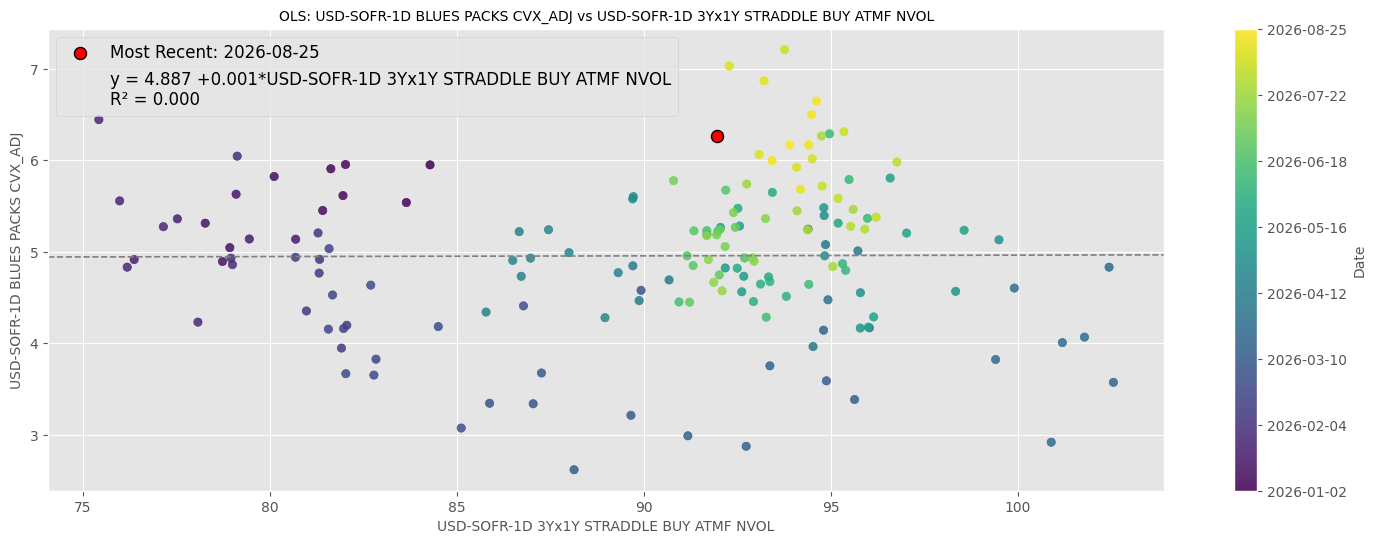

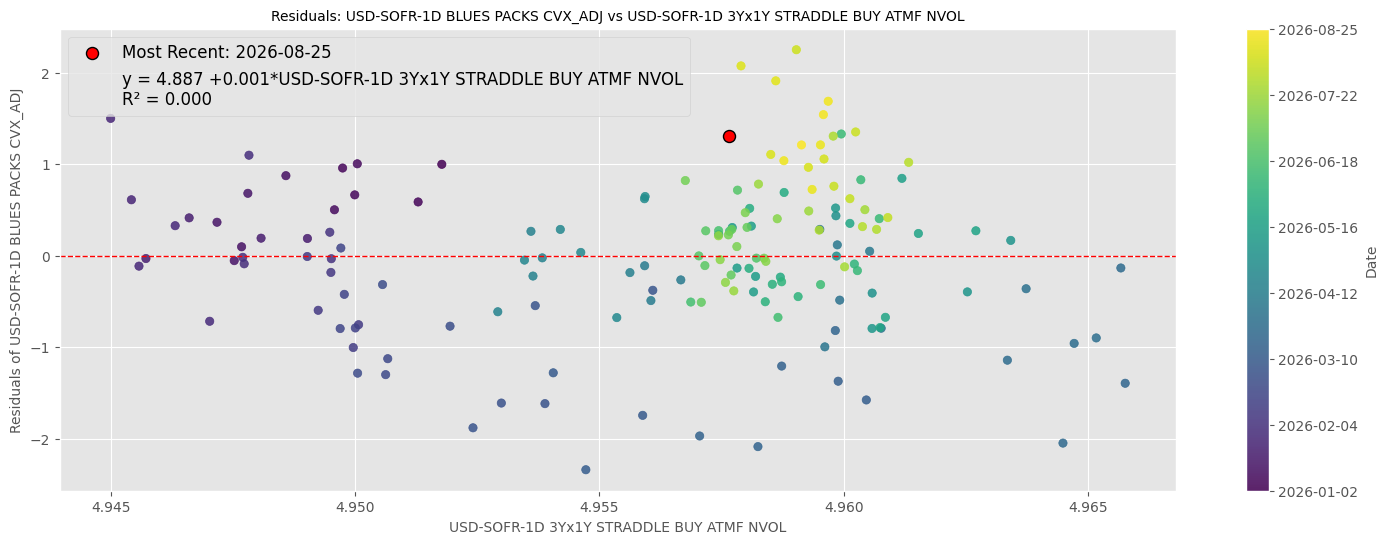

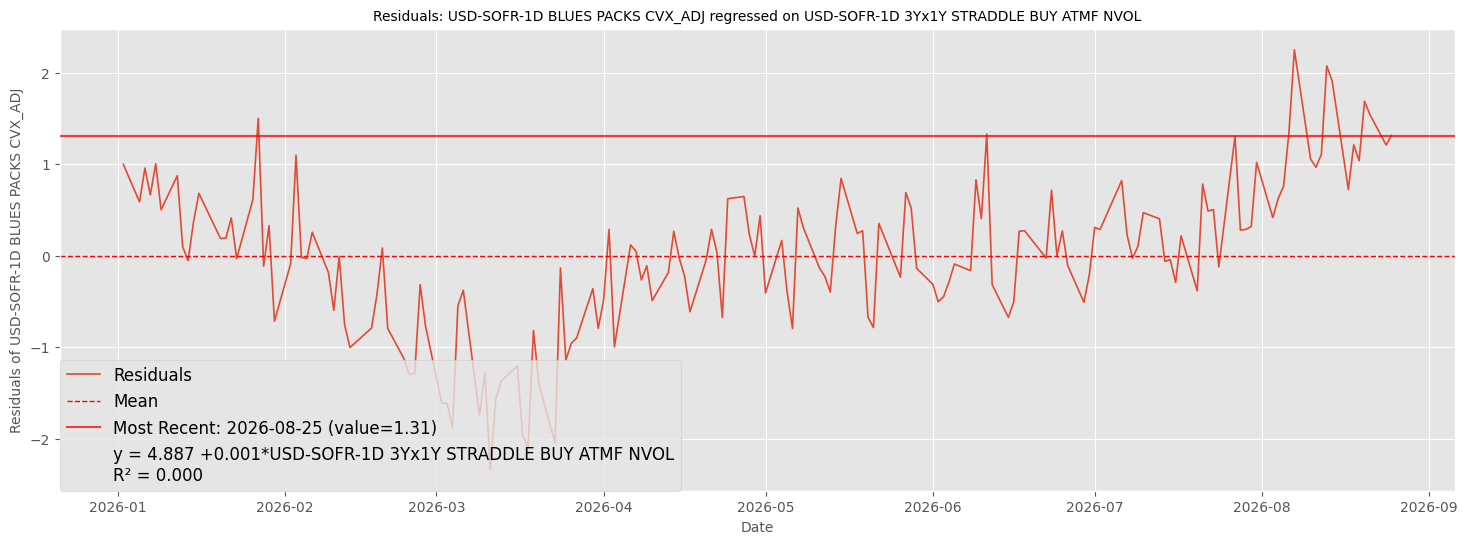

In [59]:
from RVUtils.regression import make_linear_regression_builder

start_regression = datetime.date(2026, 1, 1)
# end_regression = datetime.date(2026, 6, 16) 
end_regression = None 
if end_regression is None:
    end_regression = datetime.date.today()

regression_df = pd.merge(
    ca_df[(ca_df.index >= pd.Timestamp(start_regression)) & (ca_df.index <= pd.Timestamp(end_regression))], 
    df[(df.index >= start_regression) & (df.index <= end_regression)], 
    left_index=True, 
    right_index=True
) 

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, plot_residuals_timeseries, get_data = make_linear_regression_builder(
    df=regression_df,
    y_col="USD-SOFR-1D BLUES PACKS CVX_ADJ",
    date_color_bar=True,
	# on_diff=True
)
# add_indep_var("USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE")
# add_indep_var("USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE")
add_indep_var("USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL")

res = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()
plot_residuals_vs_predicted()
# plot_residuals_timeseries(plot_zscores=True, plot_zero=True, stds=[1, 2])
plot_residuals_timeseries(plot_zscores=False, plot_zero=True, ou_bands=False)


In [ ]:
latest = ca_df.dropna(how="all").iloc[-1]
asof = ca_df.dropna(how="all").index[-1]
print(f"as of {asof.date()}")
print(latest.reindex(COLOURS).round(3).to_string())

import plotly.graph_objects as go
_c = latest.reindex(COLOURS).dropna()
f2 = go.Figure(go.Bar(x=_c.index, y=_c.to_numpy(),
                      text=[f"{v:.2f}" for v in _c], textposition="outside"))
f2.update_layout(title=f"SFR convexity adjustment by colour, {asof.date()}",
                 yaxis_title="bp", height=380)
f2.show()

as of 2026-08-20
WHITES    0.350
REDS      0.560
GREENS    2.624
BLUES     6.648
GOLDS     9.934


In [68]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

ccp_basis_tb = IRSwapsTB(IRSwapsMDP(source="GSQUANT-RL"), show_tqdm=True, use_ts_cache=True)

PAIRS = {
    "SOFR": ("USD-SOFR-1D", "USD-SOFR-1D-CME"),   # from ~2018-08
    # "FF":   ("USD-OIS-STIR-LCH",     "USD-OIS-STIR-CME"),       # from  2010-01-04
}
TENORS = ["10Y"]

start, end = datetime.date(2026, 1, 2), datetime.date(2026, 8, 20)

ccp_basis_queries = [
    IRSwapQuery(curve=c, tenor=t, value=IRSwapValue.RATE)
    for pair in PAIRS.values() for c in pair for t in TENORS
]
ccp_basis_df = ccp_basis_tb.get_timeseries(start=start, end=end, queries=ccp_basis_queries, n_jobs=8)
ccp_basis_df

WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

PRICING USD-SOFR-1D IRSWAPS [workers=8]...:   0%|          | 0/160 [00:00<?, ?it/s]WARNING	Task(Task-2) IRSwapsTB:IRSwapsTB.py:get_timeseries()- GSQUANT-RL: no curve for 1 of 160 requested point(s) on 'USD-SOFR-1D' — those rows are ABSENT from the result, not NaN (first=2026-08-12, last=2026-08-12).
WARNING	Task(Task-2) MDP.IRSwaps.IRSwapsMDP:IRSwapsMDP.py:bulk_get_data()- Dropping GSQUANT-RL point 2026-01-19 for curve 'USD-SOFR-1D-CME': 2026-01-19 is not a business day in the US government bond market calendar!
WARNING	Task(Task-2) MDP.IRSwaps.IRSwapsMDP:IRSwapsMDP.py:bulk_get_data()- Dropping GSQUANT-RL point 2026-02-16 for curve 'USD-SOFR-1D-CME': 2026-02-16 is not a business day in the US government bond market calendar!
WARNING	Task(Task-2) MDP.IRSwaps.IRSwapsMDP:IRSwapsMDP.py:bulk_get_data()- Dropping GSQUANT-RL point 2026-05-25 for curve 'USD-SOFR-1D-CME': 2026-05-25 is not a business day in the US government bond market calendar!
WARNING	Task(Task-2) MDP.IRSwaps.IRSwapsMDP:IRSw

,USD-SOFR-1D 10y OUTRIGHT RATE,USD-SOFR-1D-CME 10y OUTRIGHT RATE
Date,,
2026-01-02,3.821289,3.819312
2026-01-05,3.796715,3.796312
2026-01-06,3.807434,3.806465
2026-01-07,3.768294,3.769060
2026-01-08,3.811191,3.811384
...,...,...
2026-08-14,4.302846,4.304081
2026-08-17,4.312941,4.332941
2026-08-18,4.294888,4.315388


In [66]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly", 
)

plot((ccp_basis_df["USD-SOFR-1D-STIR-CME 2Y OUTRIGHT RATE"] - ccp_basis_df["USD-SOFR-1D-STIR-LCH 2Y OUTRIGHT RATE"]) * 100, which="right")
legend(show_date=True)